# B4222 Project Source Code - Twitters Feature Engineering

In [8]:
# connect google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import Libraries

In [9]:
!pip install emoji
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import re
import emoji
import ast
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline

# Load Dataset

In [11]:
# load dataset (adjust path as required)
df_tweets = pd.read_parquet("datasets/final_outputs/df_tweets_final.parquet")
df = pd.read_parquet("./datasets/final_outputs/df_users_final.parquet")

# copy dataset
df_tweets = df_tweets.copy()
df = df.copy()

# Reformat tweet data to an older version to match code

In [12]:
import pandas as pd
import numpy as np

df = df_tweets.copy()

# --------------------------------------------------
# 0. Rename columns to match old tweet schema
# --------------------------------------------------
# If your tweet text is currently in "tweets", rename it back to "text"
if "tweets" in df.columns and "text" not in df.columns:
    df = df.rename(columns={"tweets": "text"})

# If your tweet id is currently in "tweet_id", rename it back to "id"
# because old nested tweet dicts use "id" for tweet id
if "tweet_id" in df.columns and "id" not in df.columns:
    df = df.rename(columns={"tweet_id": "id"})

# --------------------------------------------------
# 1. Normalize author_id to old format: u12345
# --------------------------------------------------
if "author_id" in df.columns:
    df["author_id"] = df["author_id"].astype(str)
    df["author_id"] = df["author_id"].apply(
        lambda x: x if x.startswith("u") else "u" + x
    )

# --------------------------------------------------
# 2. Build user id from author_id
# --------------------------------------------------
df["user_id"] = df["author_id"]

# --------------------------------------------------
# 3. Replace NaN with None to match old structure
# --------------------------------------------------
df = df.where(pd.notna(df), None)

# --------------------------------------------------
# 4. Build full tweet dict using ALL tweet-level columns
# --------------------------------------------------
# Exclude only the grouping key
tweet_dict_cols = [col for col in df.columns if col != "user_id"]

df["tweet_dict"] = df[tweet_dict_cols].to_dict(orient="records")

# --------------------------------------------------
# 5. Group by user
# --------------------------------------------------
df_tweets_grouped = (
    df.groupby("user_id")["tweet_dict"]
    .apply(list)
    .reset_index(name="tweets")
    .rename(columns={"user_id": "id"})
)

print(df_tweets_grouped.shape)
df_tweets_grouped.head()

(19698, 2)


,id,tweets
0,u1000230050736701441,"[{'attachments': nan, 'author_id': 'u100023005..."
1,u1000262514,"[{'attachments': nan, 'author_id': 'u100026251..."
2,u100030266,"[{'attachments': nan, 'author_id': 'u100030266..."
3,u1000408725977477120,"[{'attachments': nan, 'author_id': 'u100040872..."
4,u1000536743542771712,"[{'attachments': nan, 'author_id': 'u100053674..."


# Data Inspection

In [13]:
df_tweets = df_tweets_grouped
df_tweets.head(10)

,id,tweets
0,u1000230050736701441,"[{'attachments': nan, 'author_id': 'u100023005..."
1,u1000262514,"[{'attachments': nan, 'author_id': 'u100026251..."
2,u100030266,"[{'attachments': nan, 'author_id': 'u100030266..."
3,u1000408725977477120,"[{'attachments': nan, 'author_id': 'u100040872..."
4,u1000536743542771712,"[{'attachments': nan, 'author_id': 'u100053674..."
5,u1000562155152990208,"[{'attachments': nan, 'author_id': 'u100056215..."
6,u1000591,"[{'attachments': nan, 'author_id': 'u1000591',..."
7,u1000811205458620416,"[{'attachments': nan, 'author_id': 'u100081120..."
8,u1000955520,"[{'attachments': nan, 'author_id': 'u100095552..."
9,u1001025128,"[{'attachments': nan, 'author_id': 'u100102512..."


In [14]:
# display information of data
df_tweets.info()

<class 'pandas.DataFrame'>
RangeIndex: 19698 entries, 0 to 19697
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      19698 non-null  str   
 1   tweets  19698 non-null  object
dtypes: object(1), str(1)
memory usage: 573.8+ KB


In [15]:
# display data
df.head()

,attachments,author_id,context_annotations,conversation_id,created_at,entities,geo,id,in_reply_to_user_id,lang,possibly_sensitive,public_metrics,referenced_tweets,reply_settings,source,text,withheld,user_id,tweet_dict
0,NaN,u825766640,NaN,1497423085124800516,2022-02-26 04:07:38+00:00,"{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,t1497423085124800516,1.092509e+09,und,False,"{'retweet_count': 0, 'reply_count': None, 'lik...",NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",@hugobowne @OuterboundsHQ @_rchang @ZacharyMay...,NaN,u825766640,"{'attachments': nan, 'author_id': 'u825766640'..."
1,NaN,u825766640,NaN,1497322075060523008,2022-02-25 21:26:16+00:00,"{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,t1497322075060523008,NaN,en,False,"{'retweet_count': 30, 'reply_count': None, 'li...",NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",RT @TommyDANGerouss: Have you ever wondered ho...,NaN,u825766640,"{'attachments': nan, 'author_id': 'u825766640'..."
2,NaN,u825766640,NaN,1496942524274921472,2022-02-24 20:18:04+00:00,"{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,t1496942524274921472,NaN,en,False,"{'retweet_count': 21, 'reply_count': None, 'li...",NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",RT @jeremyphoward: This looks really exciting ...,NaN,u825766640,"{'attachments': nan, 'author_id': 'u825766640'..."
3,NaN,u825766640,NaN,1496698256167817220,2022-02-24 04:07:26+00:00,"{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,t1496698256167817220,NaN,en,False,"{'retweet_count': 5, 'reply_count': None, 'lik...",NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",RT @hugobowne: I'm excited to announce that I'...,NaN,u825766640,"{'attachments': nan, 'author_id': 'u825766640'..."
4,NaN,u825766640,NaN,1496698114530373633,2022-02-24 04:06:52+00:00,"{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,t1496698114530373633,1.387158e+18,en,False,"{'retweet_count': 0, 'reply_count': None, 'lik...",NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",@OuterboundsHQ @hugobowne LOL did you just say...,NaN,u825766640,"{'attachments': nan, 'author_id': 'u825766640'..."


In [16]:
# display information of data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5797761 entries, 0 to 5797760
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   attachments          str    
 1   author_id            str    
 2   context_annotations  str    
 3   conversation_id      int64  
 4   created_at           str    
 5   entities             str    
 6   geo                  str    
 7   id                   str    
 8   in_reply_to_user_id  float64
 9   lang                 str    
 10  possibly_sensitive   bool   
 11  public_metrics       str    
 12  referenced_tweets    str    
 13  reply_settings       str    
 14  source               str    
 15  text                 str    
 16  withheld             str    
 17  user_id              str    
 18  tweet_dict           object 
dtypes: bool(1), float64(1), int64(1), object(1), str(15)
memory usage: 5.4+ GB


## Tweets Inspection

In [17]:
# count number of users with no tweets and number of users with tweets
no_tweets_count = df_tweets['tweets'].apply(lambda x: len(x) == 0).sum()
tweets_count = df_tweets['tweets'].apply(lambda x: len(x) > 0).sum()

print("Users with no tweets: ", no_tweets_count)
print("Users with tweets: ", tweets_count)

Users with no tweets:  0
Users with tweets:  19698


In [18]:
# descriptive statistics of tweets (for all users)
df_tweets_copy = df_tweets.copy()
df_tweets_copy['num_tweets'] = df_tweets_copy['tweets'].apply(lambda x: len(x))
df_tweets_copy['num_tweets'].describe()

count    19698.000000
mean       294.332470
std        301.536602
min          1.000000
25%         88.000000
50%        213.000000
75%        343.000000
max       4612.000000
Name: num_tweets, dtype: float64

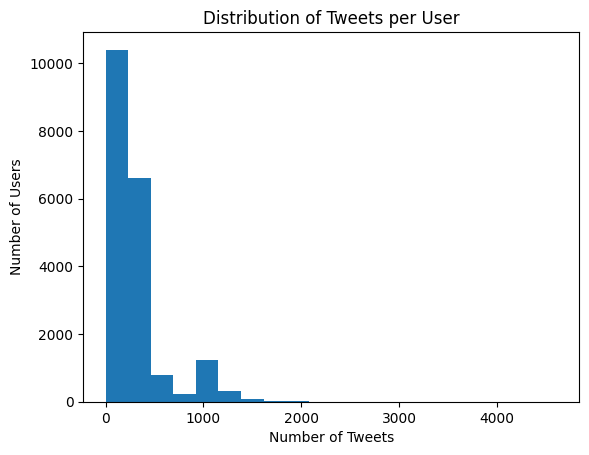

In [19]:
# histogram of tweets per user (for all users)
plt.figure()
plt.hist(df_tweets_copy['num_tweets'], bins=20)

plt.xlabel('Number of Tweets')
plt.ylabel('Number of Users')
plt.title('Distribution of Tweets per User')

plt.show()

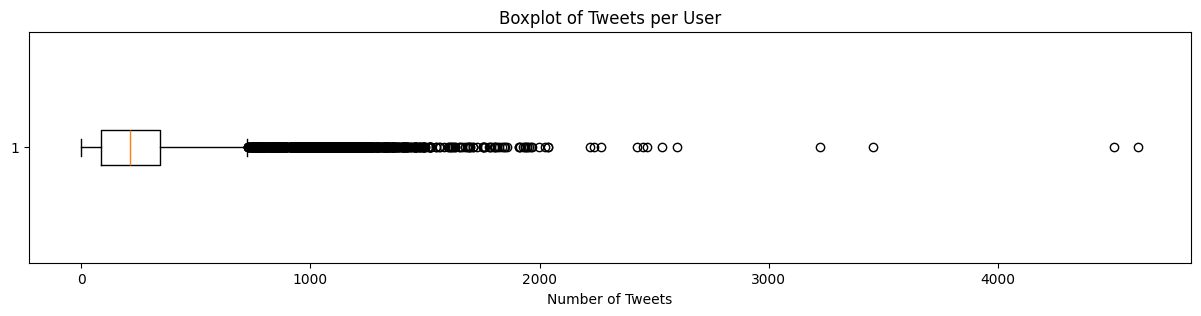

In [20]:
# boxplot of tweets per user (for all users)
plt.figure(figsize=(15, 3))
plt.boxplot(df_tweets_copy['num_tweets'], vert=False)

plt.xlabel('Number of Tweets')
plt.title('Boxplot of Tweets per User')

plt.show()

In [21]:
# descriptive statistics of tweets (for users with tweets)
df_tweets_users_with_tweets = df_tweets[df_tweets['tweets'].apply(lambda x: len(x)) > 0].copy()
df_tweets_users_with_tweets ['num_tweets'] = df_tweets_users_with_tweets ['tweets'].apply(lambda x: len(x))
df_tweets_users_with_tweets ['num_tweets'].describe()

count    19698.000000
mean       294.332470
std        301.536602
min          1.000000
25%         88.000000
50%        213.000000
75%        343.000000
max       4612.000000
Name: num_tweets, dtype: float64

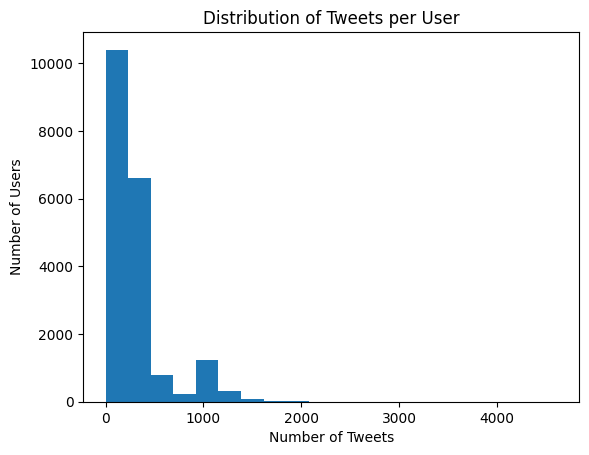

In [22]:
# histogram of tweets per user (for users with tweets)
plt.figure()
plt.hist(df_tweets_users_with_tweets ['num_tweets'], bins=20)

plt.xlabel('Number of Tweets')
plt.ylabel('Number of Users')
plt.title('Distribution of Tweets per User')

plt.show()

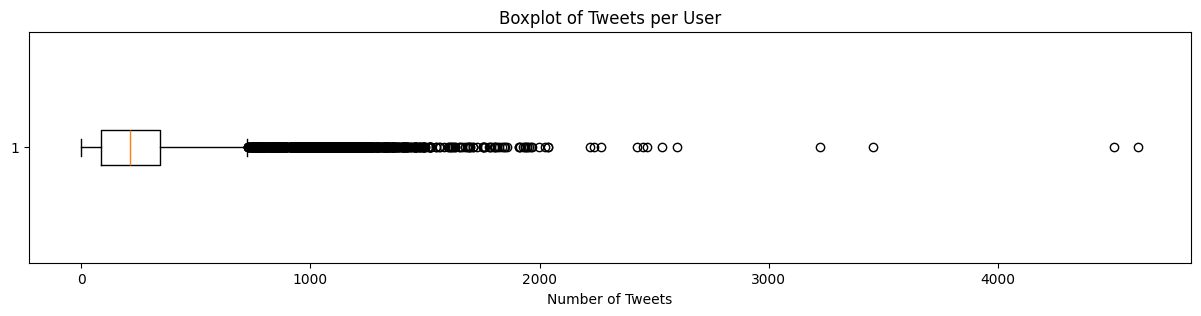

In [23]:
# boxplot of tweets per user (for users with tweets)
plt.figure(figsize=(15, 3))
plt.boxplot(df_tweets_users_with_tweets ['num_tweets'], vert=False)

plt.xlabel('Number of Tweets')
plt.title('Boxplot of Tweets per User')

plt.show()

# Feature Engineering

## User Activity Features

In [24]:
# whether or not user has tweets
df_tweets["has_tweets"] = df_tweets["tweets"].apply(lambda x: len(x) != 0).astype(int)

# number tweets
df_tweets["num_tweets"] = df_tweets["tweets"].apply(lambda x: len(x))

In [25]:
# tweet frequency -> average number of tweets per day relative to age
# lookup dictionary: user_id -> created_at
created_at_map = df.set_index('id')['created_at'].to_dict()

def compute_tweet_frequency(row):
  tweet_list = row['tweets']
  user_id = row['id']

  # number of tweets
  num_tweets = row['num_tweets']

  if num_tweets == 0:
    return 0

  # account creation date
  created_at_str = created_at_map.get(user_id)

  if created_at_str is None:
    return 0

  # parse datetime
  created_at = datetime.fromisoformat(created_at_str.replace('Z', '+00:00'))

  # current reference time
  now = datetime.now(created_at.tzinfo)

  account_age_days = (now - created_at).days

  # avoid division by 0
  if account_age_days <= 0:
    return 0

  return num_tweets / account_age_days

df_tweets['tweets_frequency'] = df_tweets.apply(compute_tweet_frequency, axis=1)

In [26]:
# posting regularity -> variance of time gaps between consecutive tweets
def compute_posting_regularity(tweet_list):
  timestamps = []

  # extract timestamps
  for t in tweet_list:
    if 'created_at' in t:
      timestamps.append(
        datetime.fromisoformat(t['created_at'].replace('Z', '+00:00'))
      )

  # edge cases
  if len(timestamps) <= 2:
    return 0  # not enough data to compute meaningful variance

  timestamps.sort()

  # compute time differences in days
  diffs = [
    (timestamps[i] - timestamps[i-1]).total_seconds() / (60*60*24)
    for i in range(1, len(timestamps))
  ]

  return np.var(diffs)

df_tweets['posting_regularity'] = df_tweets['tweets'].apply(compute_posting_regularity)

## Content Features

In [27]:
import re
import pandas as pd

# text length
def compute_text_length(tweet_list):
    lengths = []
    word_counts = []
    word_lengths = []

    # handle cases where tweet_list itself is not a list
    if not isinstance(tweet_list, list):
        return pd.Series([0, 0, 0])

    for tweet in tweet_list:
        # skip if tweet itself is not a dict
        if not isinstance(tweet, dict):
            continue

        text = tweet.get("text")

        # skip None / NaN / non-string
        if pd.isna(text):
            continue

        text = str(text).strip()
        if text == "":
            continue

        # character length
        char_len = len(text)
        lengths.append(char_len)

        # words
        words = re.findall(r"\w+", text)
        word_counts.append(len(words))

        # avg word length in this tweet
        if len(words) > 0:
            word_lengths.append(sum(len(w) for w in words) / len(words))

    # aggregate across tweets in the row
    if len(lengths) == 0:
        return pd.Series([0, 0, 0])

    avg_length = sum(lengths) / len(lengths)
    avg_words = sum(word_counts) / len(word_counts)
    avg_word_length = sum(word_lengths) / len(word_lengths) if len(word_lengths) > 0 else 0

    return pd.Series([avg_length, avg_words, avg_word_length])


df_tweets[
    ["avg_length_per_tweet", "avg_words_per_tweet", "avg_word_length_per_tweet"]
] = df_tweets["tweets"].apply(compute_text_length)

In [28]:
import pandas as pd
import emoji

# text style
def compute_text_style(tweet_list):
    uppercase_pct = []
    digit_pct = []
    special_char_pct = []
    emoji_count = []

    # handle non-list cases
    if not isinstance(tweet_list, list):
        return pd.Series([0, 0, 0, 0])

    for tweet in tweet_list:
        if not isinstance(tweet, dict):
            continue

        text = tweet.get('text')

        # skip None / NaN
        if pd.isna(text):
            continue

        text = str(text)
        total_chars = len(text)

        # avoid division by zero
        if total_chars == 0:
            continue

        uppercase_count = sum(1 for c in text if c.isupper())
        uppercase_pct.append(uppercase_count / total_chars)

        digit_count = sum(1 for c in text if c.isdigit())
        digit_pct.append(digit_count / total_chars)

        special_chars = sum(
            1 for c in text if not c.isalnum() and c not in [' ', '#', '@']
        )
        special_char_pct.append(special_chars / total_chars)

        emoji_count.append(len(emoji.emoji_list(text)))

    if len(uppercase_pct) == 0:
        return pd.Series([0, 0, 0, 0])

    return pd.Series([
        sum(uppercase_pct) / len(uppercase_pct),
        sum(digit_pct) / len(digit_pct),
        sum(special_char_pct) / len(special_char_pct),
        sum(emoji_count) / len(emoji_count)
    ])


df_tweets[
    ['avg_uppercase_pct',
     'avg_digit_pct',
     'avg_special_char_pct',
     'avg_emoji']
] = df_tweets['tweets'].apply(compute_text_style)

In [29]:
import ast
import pandas as pd

# hashtags
def compute_hashtag(tweet_list):
    hashtags_per_tweet = []
    unique_hashtags_per_tweet = []
    has_hashtag_flags = []

    if not isinstance(tweet_list, list):
        return pd.Series([0, 0, 0])

    for tweet in tweet_list:
        if not isinstance(tweet, dict):
            continue

        entities = tweet.get("entities")

        if pd.isna(entities) or not entities:
            continue

        if isinstance(entities, str):
            try:
                entities_dict = ast.literal_eval(entities)
            except Exception:
                continue
        elif isinstance(entities, dict):
            entities_dict = entities
        else:
            continue

        hashtags = entities_dict.get("hashtags", [])

        hashtag_tags = []
        for h in hashtags:
            if isinstance(h, dict):
                if "tag" in h:
                    hashtag_tags.append(str(h["tag"]))
                elif "text" in h:
                    hashtag_tags.append(str(h["text"]))

        hashtags_per_tweet.append(len(hashtag_tags))
        unique_hashtags_per_tweet.append(len(set(hashtag_tags)))
        has_hashtag_flags.append(1 if len(hashtag_tags) > 0 else 0)

    if len(hashtags_per_tweet) == 0:
        return pd.Series([0, 0, 0])

    avg_hashtags = sum(hashtags_per_tweet) / len(hashtags_per_tweet)
    avg_unique_hashtags = sum(unique_hashtags_per_tweet) / len(unique_hashtags_per_tweet)
    pct_tweets_with_hashtags = sum(has_hashtag_flags) / len(has_hashtag_flags)

    overuse_hashtags = 1 if avg_unique_hashtags < avg_hashtags else 0

    return pd.Series([avg_hashtags, overuse_hashtags, pct_tweets_with_hashtags])

df_tweets[
    ["avg_hashtags_per_tweet", "overuse_hashtags", "pct_tweets_with_hashtags"]
] = df_tweets["tweets"].apply(compute_hashtag)

# make overuse_hashtags binary
df_tweets["overuse_hashtags"] = df_tweets["overuse_hashtags"].astype(int)

In [30]:
import ast
import pandas as pd

# mentions
def compute_mention(tweet_list):
    mentions_per_tweet = []
    has_mentions_flags = []

    if not isinstance(tweet_list, list):
        return pd.Series([0, 0])

    for tweet in tweet_list:
        if not isinstance(tweet, dict):
            continue

        entities = tweet.get("entities")

        if pd.isna(entities) or not entities:
            continue

        if isinstance(entities, str):
            try:
                entities_dict = ast.literal_eval(entities)
            except Exception:
                continue
        elif isinstance(entities, dict):
            entities_dict = entities
        else:
            continue

        mentions = entities_dict.get("mentions") or entities_dict.get("user_mentions") or []

        mentions_per_tweet.append(len(mentions))
        has_mentions_flags.append(1 if len(mentions) > 0 else 0)

    if len(mentions_per_tweet) == 0:
        return pd.Series([0, 0])

    avg_mentions = sum(mentions_per_tweet) / len(mentions_per_tweet)
    pct_tweets_with_mentions = sum(has_mentions_flags) / len(has_mentions_flags)

    return pd.Series([avg_mentions, pct_tweets_with_mentions])

df_tweets[
    ["avg_mentions_per_tweet", "pct_tweets_with_mentions"]
] = df_tweets["tweets"].apply(compute_mention)

In [31]:
import ast
import pandas as pd

# urls
def compute_url(tweet_list):
    urls_per_tweet = []
    has_urls_flags = []

    if not isinstance(tweet_list, list):
        return pd.Series([0, 0])

    for tweet in tweet_list:
        if not isinstance(tweet, dict):
            continue

        entities = tweet.get("entities")

        if pd.isna(entities) or not entities:
            continue

        if isinstance(entities, str):
            try:
                entities_dict = ast.literal_eval(entities)
            except Exception:
                continue
        elif isinstance(entities, dict):
            entities_dict = entities
        else:
            continue

        urls = entities_dict.get("urls", [])

        urls_per_tweet.append(len(urls))
        has_urls_flags.append(1 if len(urls) > 0 else 0)

    if len(urls_per_tweet) == 0:
        return pd.Series([0, 0])

    avg_urls = sum(urls_per_tweet) / len(urls_per_tweet)
    pct_tweets_with_urls = sum(has_urls_flags) / len(has_urls_flags)

    return pd.Series([avg_urls, pct_tweets_with_urls])

df_tweets[
    ["avg_urls_per_tweet", "pct_tweets_with_urls"]
] = df_tweets["tweets"].apply(compute_url)

In [32]:
import ast
import pandas as pd

# media/attachment
def compute_attachment(tweet_list):
    attachments_per_tweet = []
    has_attachments_flags = []

    if not isinstance(tweet_list, list):
        return pd.Series([0, 0])

    for tweet in tweet_list:
        if not isinstance(tweet, dict):
            continue

        attachments = tweet.get("attachments")

        # skip NaN / None
        if pd.isna(attachments) or not attachments:
            continue

        # handle stringified attachments
        if isinstance(attachments, str):
            try:
                attachments = ast.literal_eval(attachments)
            except Exception:
                continue

        # extract number of attachments
        if isinstance(attachments, dict):
            # typical structure: {"media_keys": [...]}
            media_keys = attachments.get("media_keys", [])
            n = len(media_keys) if isinstance(media_keys, list) else 0
        elif isinstance(attachments, list):
            n = len(attachments)
        else:
            continue

        attachments_per_tweet.append(n)
        has_attachments_flags.append(1 if n > 0 else 0)

    if len(attachments_per_tweet) == 0:
        return pd.Series([0, 0])

    avg_attachments = sum(attachments_per_tweet) / len(attachments_per_tweet)
    pct_tweets_with_attachments = sum(has_attachments_flags) / len(has_attachments_flags)

    return pd.Series([avg_attachments, pct_tweets_with_attachments])


df_tweets[
    ["avg_attachments_per_tweet", "pct_tweets_with_attachments"]
] = df_tweets["tweets"].apply(compute_attachment)

In [33]:
# sensitivity
def compute_sensitivity(tweet_list):
  sensitivity_per_tweet = []

  for tweet in tweet_list:
    sensitivity = tweet.get('possibly_sensitive', False)
    sensitivity_per_tweet.append(1 if sensitivity else 0)

  if len(sensitivity_per_tweet) == 0:
    return 0
  else:
    return sum(sensitivity_per_tweet) / len(sensitivity_per_tweet)

df_tweets["avg_sensitive"] = df_tweets['tweets'].apply(compute_sensitivity)

### Sentiment Analysis

In [37]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import pandas as pd
import torch

# ----------------------------
# 1. setup model
# ----------------------------
model_name = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = -1  # CPU
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device
)

# ----------------------------
# 2. flatten only latest 20 tweets/user
# ----------------------------
all_texts = []
tweet_counts = []

MAX_TWEETS_PER_USER = 20
MAX_CHARS = 64

for tweet_list in df_tweets["tweets"]:
    texts = []

    if isinstance(tweet_list, list):
        for t in tweet_list[-MAX_TWEETS_PER_USER:]:
            if not isinstance(t, dict):
                continue

            text = t.get("text")
            if pd.isna(text):
                continue

            text = str(text).strip()
            if text == "":
                continue

            texts.append(text[:MAX_CHARS])

    all_texts.extend(texts)
    tweet_counts.append(len(texts))

print("Total texts to score:", len(all_texts))

# ----------------------------
# 3. run in chunks
# ----------------------------
all_results = []
CHUNK_SIZE = 5000
BATCH_SIZE = 128

for i in range(0, len(all_texts), CHUNK_SIZE):
    print(f"Processing {i} to {min(i + CHUNK_SIZE, len(all_texts))} ...")
    chunk = all_texts[i:i + CHUNK_SIZE]

    chunk_results = sentiment_pipeline(
        chunk,
        batch_size=BATCH_SIZE,
        truncation=True
    )
    all_results.extend(chunk_results)

# ----------------------------
# 4. map labels
# ----------------------------
mapped_sentiments = []

for r in all_results:
    label = r["label"]
    if label == "LABEL_2":
        mapped_sentiments.append("positive")
    elif label == "LABEL_0":
        mapped_sentiments.append("negative")
    else:
        mapped_sentiments.append("neutral")

# ----------------------------
# 5. reconstruct row-level features
# ----------------------------
idx = 0
features = []

for count in tweet_counts:
    if count == 0:
        features.append([0, 0, 0])
        continue

    subset = mapped_sentiments[idx: idx + count]
    idx += count

    total = len(subset)
    pos = subset.count("positive") / total
    neg = subset.count("negative") / total
    neu = subset.count("neutral") / total

    features.append([pos, neg, neu])

df_tweets[["avg_positive", "avg_negative", "avg_neutral"]] = pd.DataFrame(
    features,
    index=df_tweets.index
)

print(df_tweets[["avg_positive", "avg_negative", "avg_neutral"]].head())

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 80184.05it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total texts to score: 387787
Processing 0 to 5000 ...
Processing 5000 to 10000 ...
Processing 10000 to 15000 ...
Processing 15000 to 20000 ...
Processing 20000 to 25000 ...
Processing 25000 to 30000 ...
Processing 30000 to 35000 ...
Processing 35000 to 40000 ...
Processing 40000 to 45000 ...
Processing 45000 to 50000 ...
Processing 50000 to 55000 ...
Processing 55000 to 60000 ...
Processing 60000 to 65000 ...
Processing 65000 to 70000 ...
Processing 70000 to 75000 ...
Processing 75000 to 80000 ...
Processing 80000 to 85000 ...
Processing 85000 to 90000 ...
Processing 90000 to 95000 ...
Processing 95000 to 100000 ...
Processing 100000 to 105000 ...
Processing 105000 to 110000 ...
Processing 110000 to 115000 ...
Processing 115000 to 120000 ...
Processing 120000 to 125000 ...
Processing 125000 to 130000 ...
Processing 130000 to 135000 ...
Processing 135000 to 140000 ...
Processing 140000 to 145000 ...
Processing 145000 to 150000 ...
Processing 150000 to 155000 ...
Processing 155000 to 160

## Interaction Features

In [38]:
# type of tweets
def compute_tweet_types(tweet_list):
  retweets = 0
  quotes = 0
  replies = 0
  originals = 0

  for tweet in tweet_list:
    ref = tweet.get("referenced_tweets")
    ref_types = []

    # parse referenced_tweets if needed
    if ref is not None:
      if isinstance(ref, str):
        try:
          ref = ast.literal_eval(ref)
        except:
          ref = None

      if isinstance(ref, list):
        ref_types = [r.get("type") for r in ref if isinstance(r, dict)]

    reply_flag = tweet.get("in_reply_to_user_id") is not None

    is_reply = reply_flag or ("replied_to" in ref_types)
    is_retweet = "retweeted" in ref_types
    is_quote = "quoted" in ref_types

    # classify
    if is_reply:
      replies += 1
    if is_retweet:
      retweets += 1
    if is_quote:
      quotes += 1
    if not (is_reply or is_retweet or is_quote):
      originals += 1

  num_tweets = len(tweet_list)

  if num_tweets == 0:
    return pd.Series([0, 0, 0, 0])
  else:
    return pd.Series([
        retweets / num_tweets,
        quotes / num_tweets,
        replies / num_tweets,
        originals / num_tweets
    ])

df_tweets[["avg_retweets", "avg_quotes", "avg_replies", "avg_originals"]] = (
  df_tweets["tweets"].apply(lambda x: pd.Series(compute_tweet_types(x)))
)

## Engagement Features

In [39]:
def compute_engagement(tweet_list):
  retweets_per_tweet = []
  replies_per_tweet = []
  likes_per_tweet = []
  quotes_per_tweet = []
  engagement_rate_per_tweet = []

  for tweet in tweet_list:
    metrics = tweet.get('public_metrics')

    if not metrics:
      continue

    if isinstance(metrics, str):
      try:
        metrics_dict = ast.literal_eval(metrics)
      except:
        continue
    else:
      metrics_dict = metrics

    retweets_per_tweet.append(metrics_dict.get('retweet_count') or 0)
    replies_per_tweet.append(metrics_dict.get('reply_count') or 0)
    likes_per_tweet.append(metrics_dict.get('like_count') or 0)
    quotes_per_tweet.append(metrics_dict.get('quote_count') or 0)

  if len(tweet_list) == 0:
    return pd.Series([0, 0, 0, 0, 0])

  avg_likes = sum(likes_per_tweet) / len(likes_per_tweet)
  avg_retweets = sum(retweets_per_tweet) / len(retweets_per_tweet)
  avg_replies = sum(replies_per_tweet) / len(replies_per_tweet)
  avg_quotes = sum(quotes_per_tweet) / len(quotes_per_tweet)

  engagement_rate = (
      sum(likes_per_tweet) +
      sum(retweets_per_tweet) +
      sum(replies_per_tweet) +
      sum(quotes_per_tweet)
  ) / len(tweet_list)

  return pd.Series([avg_likes, avg_retweets, avg_replies, avg_quotes, engagement_rate])

df_tweets[['avg_likes_per_tweet',
           'avg_retweets_per_tweet',
           'avg_replies_per_tweet',
           'avg_quotes_per_tweet',
           'engagement_rate']] = df_tweets['tweets'].apply(compute_engagement)

In [40]:
# reply settings
def compute_reply_settings(tweet_list):
  reply_settings_flags = []

  for tweet in tweet_list:
    reply_settings = tweet.get('reply_settings')

    reply_settings_flags.append(1 if reply_settings is not None else 0)

  if len(reply_settings_flags) == 0:
    return 0

  pct_reply_settings = sum(reply_settings_flags) / len(reply_settings_flags)

  return pct_reply_settings

df_tweets['pct_allow_reply'] = df_tweets['tweets'].apply(compute_reply_settings)

In [41]:
# feature crossing between reply settings and number of replies
def compute_fc_reply(tweet_list):
  total_replies = 0
  count_allow_reply = 0

  if len(tweet_list) == 0:
      return 0

  for tweet in tweet_list:
    # reply settings
    reply_settings = tweet.get('reply_settings')
    reply_settings_flag = 1 if reply_settings is not None else 0

    # replies
    metrics = tweet.get('public_metrics')

    if not metrics:
      continue

    if isinstance(metrics, str):
      try:
        metrics_dict = ast.literal_eval(metrics)
      except:
        continue
    else:
      metrics_dict = metrics

    reply_count = metrics_dict.get('reply_count') or 0

    total_replies += reply_count
    count_allow_reply += reply_settings_flag

  if count_allow_reply == 0:
    return 0
  else:
    return total_replies / count_allow_reply

df_tweets['fc_reply'] = df_tweets['tweets'].apply(compute_fc_reply)

## Other Features

In [42]:
# language
def compute_language(tweet_list):
    langs = []

    for tweet in tweet_list:
        lang = tweet.get('lang')

        if not lang:
            continue

        langs.append(lang)

    if len(langs) == 0:
        return 0

    num_unique_langs = len(set(langs))

    return num_unique_langs

df_tweets['num_unique_langs'] = df_tweets['tweets'].apply(compute_language)

In [43]:
# geo-enabled
def compute_geo(tweet_list):
    geo_flags = []

    for tweet in tweet_list:
        geo = tweet.get('geo')

        geo_flags.append(1 if geo is not None else 0)

    if len(geo_flags) == 0:
        return 0

    pct_geo = sum(geo_flags) / len(geo_flags)

    return pct_geo

df_tweets['pct_geo_tweets'] = df_tweets['tweets'].apply(compute_geo)

## Suspicious Behaviour

In [44]:
def count_inconsistencies(tweet_list):
  has_inconsistencies = 0
  count = 0

  for tweet in tweet_list:
    ref = tweet.get("referenced_tweets")
    ref_is_none = ref is None

    ref_types = []

    if ref is not None:
      if isinstance(ref, str):
        try:
          ref = ast.literal_eval(ref)
        except:
          ref = None

      if isinstance(ref, list):
        ref_types = [r.get("type") for r in ref if isinstance(r, dict)]

    reply_flag = tweet.get("in_reply_to_user_id") is not None
    is_reply_ref = "replied_to" in ref_types

    # inconsistency condition
    if (reply_flag and ref_is_none) or (not reply_flag and is_reply_ref):
      count += 1

  if (count != 0):
      has_inconsistencies = 1

  return pd.Series([has_inconsistencies, count])

df_tweets[["has_reply_inconsistency", "reply_inconsistency_count"]] = df_tweets["tweets"].apply(count_inconsistencies)

# Summary

Total number of features: 39 \
Number of numerical features: 36 \
Number of binary features: 3 -> `has_tweets`, `overuse_hashtags`, `has_reply_inconsistency`
*   User Activity
    *   whether or not user has tweets `has_tweets`
    *   total number of tweets `num_tweets`
    *   tweet frequency -> average number of tweets per day relative to age `tweet_frequency`
    *   posting regularity -> variance of time gaps between consecutive tweets (in days) `posting_regularity`
*   Content Features
    *   Text Length
        *   average length per tweet `avg_length_per_tweet`
        *   average number of words per tweet `avg_words_per_tweet`
        *   average word length per tweet `avg_word_length_per_tweet`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
    *   Text Style
        *   average percentage of uppercase characters in a tweet `avg_uppercase_pct`
        *   average percentage of digits in a tweet `avg_digit_pct`
        *   average percentage of special characters in a tweet (excluding # and @) `avg_special_char_pct`
        *   average number of emojis per tweet `avg_emoji`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
    *   Hashtags
        *   average number of hashtags per tweet `avg_hashtags_per_tweet`
        *   whether or not the same hashtag is used twice in a tweet `overuse_hashtags`
        *   percentage of tweets with hashtags `pct_tweets_with_hashtags`
    *   Mentions
        *   average number of mentions per tweet `avg_mentions_per_tweet`
        *   percentage of tweets with mentions `pct_tweets_with_mentions`
    *   URLs
        *   average number of URLs per tweet `avg_urls_per_tweet`
        *   percentage of tweets with URLs `pct_tweets_with_urls`
    *   Attachments
        *   average number of attachments per tweet `avg_attachments_per_tweet`
        *   percentage of tweets with attachments `pct_tweets_with_attachments`
    *   Sensitivity of tweet
        *   average number of sensitive tweets `avg_sensitive`
    *   Sentiment Analysis
        *   average number of positive tweets `avg_positive`
        *   average number of negative tweets `avg_negative`
        *   average number of neutral tweets `avg_neutral`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
*   Interaction Features
    *   average number of retweets `avg_retweets`
    *   average number of quoted tweets `avg_quotes`
    *   average number of tweets that are replies to other users `avg_replies`
    *   average number of original tweets `avg_originals`
*   Engagement Features
    *   average number of likes per tweet `avg_likes_per_tweet`
    *   average number of retweets per tweet `avg_retweets_per_tweet`
    *   average number of replies per tweet `avg_replies_per_tweet`
    *   average number of quotes per tweet `avg_quotes_per_tweet`
    *   engagement rate `engagement_rate`
    *   percentage of tweets with reply settings enabled `pct_allow_reply`
    *   feature crossing between reply settings and number of replies `fc_reply`
*   Other Features
    *   total number of languages used `num_unique_langs`
    *   percentage of geo-enabled tweets `pct_geo_tweets`   
*   Suspicious behaviour
    *   whether or not user has reply inconsistencies `has_reply_inconsistency`
    *   number of reply inconsistencies -> count of inconsistent behaviour between in_reply_to_user_id and type of referenced_tweets `reply_inconsistency_count`



In [45]:
# display data with new features
df_tweets.head()

,id,tweets,has_tweets,num_tweets,tweets_frequency,posting_regularity,avg_length_per_tweet,avg_words_per_tweet,avg_word_length_per_tweet,avg_uppercase_pct,...,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,has_reply_inconsistency,reply_inconsistency_count
0,u1000230050736701441,"[{'attachments': nan, 'author_id': 'u100023005...",1,377,0,7.711959,70.602122,11.726790,5.204585,0.073701,...,3.355438,0.673740,0.119363,30.872679,1.0,0.673740,2,1.0,0,0
1,u1000262514,"[{'attachments': nan, 'author_id': 'u100026251...",1,42,0,5785.718140,137.571429,26.976190,3.958661,0.049376,...,1775.261905,0.000000,0.000000,4734.357143,1.0,0.000000,1,1.0,0,0
2,u100030266,"[{'attachments': nan, 'author_id': 'u100030266...",1,70,0,1729.655346,144.828571,25.428571,4.668478,0.050630,...,16.414286,0.028571,0.071429,51.342857,1.0,0.028571,2,1.0,0,0
3,u1000408725977477120,"[{'attachments': nan, 'author_id': 'u100040872...",1,40,0,0.271123,101.025000,14.650000,5.764211,0.102424,...,313.300000,0.000000,0.000000,314.300000,1.0,0.000000,6,1.0,0,0
4,u1000536743542771712,"[{'attachments': nan, 'author_id': 'u100053674...",1,181,0,744.370997,152.226519,24.867403,5.341575,0.041757,...,44.038674,0.988950,0.243094,159.966851,1.0,0.988950,4,1.0,0,0


In [46]:
# display types of features
df_tweets.info()

<class 'pandas.DataFrame'>
RangeIndex: 19698 entries, 0 to 19697
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           19698 non-null  str    
 1   tweets                       19698 non-null  object 
 2   has_tweets                   19698 non-null  int64  
 3   num_tweets                   19698 non-null  int64  
 4   tweets_frequency             19698 non-null  int64  
 5   posting_regularity           19698 non-null  float64
 6   avg_length_per_tweet         19698 non-null  float64
 7   avg_words_per_tweet          19698 non-null  float64
 8   avg_word_length_per_tweet    19698 non-null  float64
 9   avg_uppercase_pct            19698 non-null  float64
 10  avg_digit_pct                19698 non-null  float64
 11  avg_special_char_pct         19698 non-null  float64
 12  avg_emoji                    19698 non-null  float64
 13  avg_hashtags_per_tweet     

In [47]:
# display descriptive statistics of numeric features
non_numeric_cols = ['id', 'tweets', 'has_tweets', 'overuse_hashtags', 'has_reply_inconsistency']
numeric_cols = df_tweets.columns.difference(non_numeric_cols)

df_tweets[numeric_cols].describe()

,avg_attachments_per_tweet,avg_digit_pct,avg_emoji,avg_hashtags_per_tweet,avg_length_per_tweet,avg_likes_per_tweet,avg_mentions_per_tweet,avg_negative,avg_neutral,avg_originals,...,num_unique_langs,pct_allow_reply,pct_geo_tweets,pct_tweets_with_attachments,pct_tweets_with_hashtags,pct_tweets_with_mentions,pct_tweets_with_urls,posting_regularity,reply_inconsistency_count,tweets_frequency
count,19698.000000,19698.000000,19698.000000,19698.000000,19698.000000,19698.000000,19698.000000,19698.000000,19698.000000,19698.0,...,19698.000000,19698.0,19698.0,19698.000000,19698.000000,19698.000000,19698.000000,1.969800e+04,19698.0,19698.0
mean,0.619710,0.019777,0.411399,0.746024,137.505546,500.533435,1.162618,0.089582,0.683558,0.0,...,4.927658,1.0,1.0,0.517365,0.255960,0.670714,0.328250,4.199164e+03,0.0,0.0
std,0.689698,0.013907,0.694816,1.721525,48.097267,4322.498702,1.228659,0.110651,0.194000,0.0,...,3.733697,0.0,0.0,0.497292,0.276701,0.275172,0.269656,5.889880e+04,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.0
25%,0.000000,0.012643,0.052632,0.055024,106.500000,0.975000,0.739595,0.000000,0.550000,0.0,...,2.000000,1.0,1.0,0.000000,0.041667,0.526316,0.124663,1.744797e+01,0.0,0.0
50%,1.000000,0.016734,0.194546,0.208037,132.132509,5.478806,1.081602,0.050000,0.700000,0.0,...,4.000000,1.0,1.0,0.969231,0.144578,0.742457,0.252427,2.482268e+02,0.0,0.0
75%,1.000000,0.022703,0.507002,0.691358,162.898243,42.250758,1.418506,0.150000,0.850000,0.0,...,6.000000,1.0,1.0,1.000000,0.389450,0.883833,0.461538,1.584478e+03,0.0,0.0
max,4.000000,0.356717,33.000000,26.789474,755.016393,212216.674419,48.147541,1.000000,1.000000,0.0,...,38.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,5.190790e+06,0.0,0.0


In [48]:
# display information of binary features
print("has_tweets counts:")
print(df_tweets['has_tweets'].value_counts())

print("\noveruse_hashtags counts:")
print(df_tweets['overuse_hashtags'].value_counts())

print("\nhas_reply_inconsistency counts:")
print(df_tweets['has_reply_inconsistency'].value_counts())

has_tweets counts:
has_tweets
1    19698
Name: count, dtype: int64

overuse_hashtags counts:
overuse_hashtags
0    15595
1     4103
Name: count, dtype: int64

has_reply_inconsistency counts:
has_reply_inconsistency
0    19698
Name: count, dtype: int64


# Export Features

In [ ]:
!pip install pyarrow

In [ ]:
df_tweets.to_parquet(".datasets/final_outputs/df_tweets_model.parquet", index=False)

# from google.colab import files
# files.download("df_tweets_model.parquet")